# Fitting Example (NLSF & MLE) - Bi-exponential FLI data processing

A simulated, full 3-D fluorescence lifetime image dataset of a two-well plate is generated (using the same simulator as the "Whole Image Simulation" example). Each well is assigned a different set of lifetime / FRET parameters. The data is then processed with fitted pixel by pixel with two estimators and the phasor method:

- **Non-linear least squares (NLSF)**: minimizes the sum of squared residuals between the IRF-convolved model and the decay. It is fast and works well when photon counts are high, since the noise is then close to Gaussian.
- **Maximum likelihood estimation (MLE)**: maximizes the Poisson log-likelihood of the photon counts. It models the counting statistics directly, so it remains accurate at low photon counts, where least squares becomes biased.

This example walks through:
- Simulating the two-well FLI data and inspecting the ground-truth parameters
- Comparing NLSF and MLE on a single pixel
- Fitting the whole image with NLSF and with MLE
- Comparing the fitted maps and their distributions with the ground truth
- Inspecting the fit and residuals at individual pixels
- The phasor computation, with pixel-wise IRF calibration to benchmark the results.
- Phasor plot and pixel-wise phasor color overlays

<small>Author - Vikas</small>

In [1]:
## importing the modules required for this work
import sys

import numpy as np

sys.path.insert(0, "ex_helper")  # local helper for synthetic image generation

from sim_general_image import ROIMaskGenerator

from pyfli.analysis.utils import random_true_pixel
from pyfli.analyticalWorkflow import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.data_text import MessageDisplay
from pyfli.data_vnp import ColorProcessor, DataViewer
from pyfli.io import DataOperations
from pyfli.phasor.phasorS import PhasorAnalyzer
from pyfli.simulator import FLIModelImageGenerator

## Loading the IRF

The instrument response function (IRF) is convolved with the decay model during both simulation and fitting. Its number of time gates also sets the gate width and the laser/acquisition frequencies used by the phasor analysis and the fitters.

In [ ]:
# Path to the local IRF file
IRF_PATH = "<select file/folder path>"

In [3]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()

gate_delay = 12.5 / irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(
    laser_period=12.5, gate_delay=gate_delay, num_gate=num_gates
).freq_computation()

INFO:pyfli:Initiating IRF load from: <select file/folder path>


## Simulation configuration

`MODEL_TYPE` selects the decay model for both the simulation and the fits. `get_config` builds a per-well configuration by overriding `BASE_CONFIG`.

In [4]:
# select the type of decay model to simulate
MODEL_TYPE = "bi-exponential"
if MODEL_TYPE == "bi-exponential":
    mono_fraction = 0.0
elif MODEL_TYPE == "mono-exponential":
    mono_fraction = 1.0
else:
    mono_fraction = 0.4  # fraction of mono-exponential model in sampled data

# Your constant, default configuration
BASE_CONFIG = {
    # Modular Noise
    "jitter": False,  # offset artifact (due to jitter)
    "dcr_on": True,  # Dark Count Rate (thermal background)
    "poisson": False,  # Shot noise — Large detector only
    "qe_on": True,  # Quantum efficiency scaling
    "read_noise_on": False,  # Gaussian read noise — Large detector only
    # Sensor
    "sensor_type": "discrete",  # "continuous" | "discrete"
    "bit": 12,
    "dcr": 0.08,  # Mean dark counts per bin
    "laser_feq": freq[1],  # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on": True,  # Round photon counts to integers — Macro_sim only
    "clip_on": True,  # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count
    # Fluorescence Physics (FLI / FRET)
    "tau2": (1, 1),  # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist": "beta",  # if dist "beta" or "normal" (default)
    "tau2_beta_range": (2.5, 0.1),
    "efficiency": (1, 1),  # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction": (1, 1),  # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count": (2, 5),  # Peak intensity ~ Beta(2, 5) × max_adc - large detectors
    "mono_fraction": mono_fraction,  # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles": (1_500_000, 2_000_000),  # Accumulation cycles — for photon counter
}

In [5]:
def get_config(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG.copy()
    config.update(kwargs)
    return config


In [6]:
# Shared plotting / phasor configuration used by the two-well example below
colorset = "rainbow"
freq_hz = freq[1] * 1e6
jet_m_well = ColorProcessor().lowest_zero("jet")
bg_color = "black"  # either "black" or "white"
ph_cols_ = "viridis_r"


## Two wells example

A two-well plate is simulated, with each well assigned a different set of ground-truth lifetime / FRET parameters.

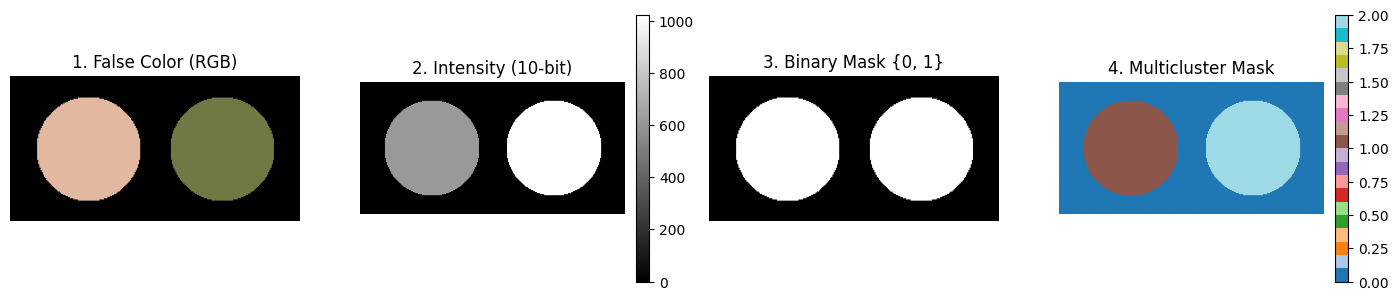

In [7]:
from sim_general_image import WellPlateShape

h_well, w_well = 128, 256
generator_well = ROIMaskGenerator((h_well, w_well), top=10, bottom=10, left=10, right=10)
TwoWells = WellPlateShape(rows=1, cols=2, gap=0.15)

custom_intensities_well = [ 0.6, 1.0]
_ = generator_well.plot_preview(
    TwoWells,
    bit_depth=10,
    intensities=custom_intensities_well,
    show=True,
)

In [ ]:
ROI0_well = {}
ROI1_well = get_config(
    tau2_beta_range=(0.1, 1.8),
    efficiency = (5, 2),  
    A1_fraction = (7, 13),
)
ROI2_well = get_config(
    tau2_beta_range=(0.2, 0.8),
    efficiency = (10, 10),  
    A1_fraction = (15, 10),
)

In [9]:
img_intensity_well = generator_well.generate_intensity_image(
    TwoWells, intensities=custom_intensities_well
)
img_cluster_well = generator_well.generate_cluster_mask(TwoWells)
b_bool_mask_well = generator_well.generate_binary_mask(TwoWells)

simulated_img_well = FLIModelImageGenerator(
    irf_data=irf_data[120, 40, :],
    intensity_image=img_intensity_well,
    roi_mask=img_cluster_well,
    roi_params=[ROI0_well, ROI1_well, ROI2_well],
    method="PHOTON_COUNTER",
    verbose=True,
    bool_mask=b_bool_mask_well,
)

gt_data_well = simulated_img_well.generate_image()

INFO:pyfli:Generating PHOTON_COUNTER FLI Image [128x256x256]...


Check the decay, IRF, and fit at a randomly selected pixel.

the non-zero pixel selected for probing is (40, 191)


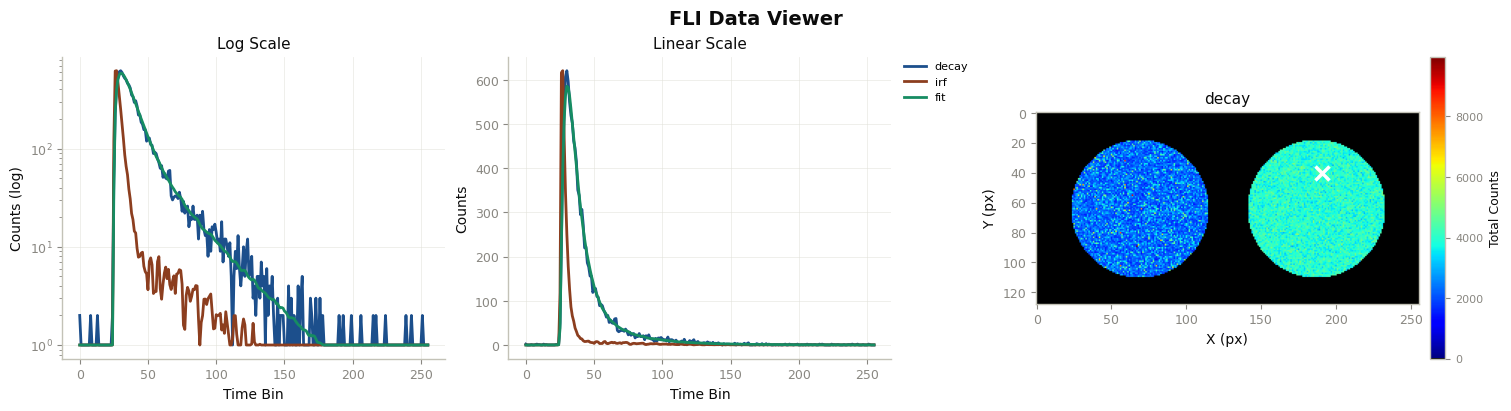

INFO:pyfli:
  Pixel (40, 191)
  ─────────────────────
  A         11159.4473
  α         0.7028
  τ₁        0.4151
  τ₂        0.8278
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   0.0000
  h-shift   —
  ─────────────────────



In [10]:
_decay_well = gt_data_well["raw_data"]["decay"]
_irf_well = gt_data_well["raw_data"]["irf"]
x_well, y_well = random_true_pixel(b_bool_mask_well)
TRs_well = gt_data_well["results"]["TR_maps"]
maps_well = gt_data_well["results"]["maps"]
print(f"the non-zero pixel selected for probing is ({x_well}, {y_well})")
irf_norm_well = Normalization(_irf_well).norm_scale(_decay_well)
DataViewer().plot_fli_px(
    data_list=[_decay_well, irf_norm_well, TRs_well["fit_map"], TRs_well["residual_map"]],
    pixel=(x_well, y_well),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m_well,
)
_ = MessageDisplay().get_pixel_summary(data_maps=maps_well, px=(x_well, y_well))

Distribution of the simulated ground-truth parameters across the image, before computing phasors.

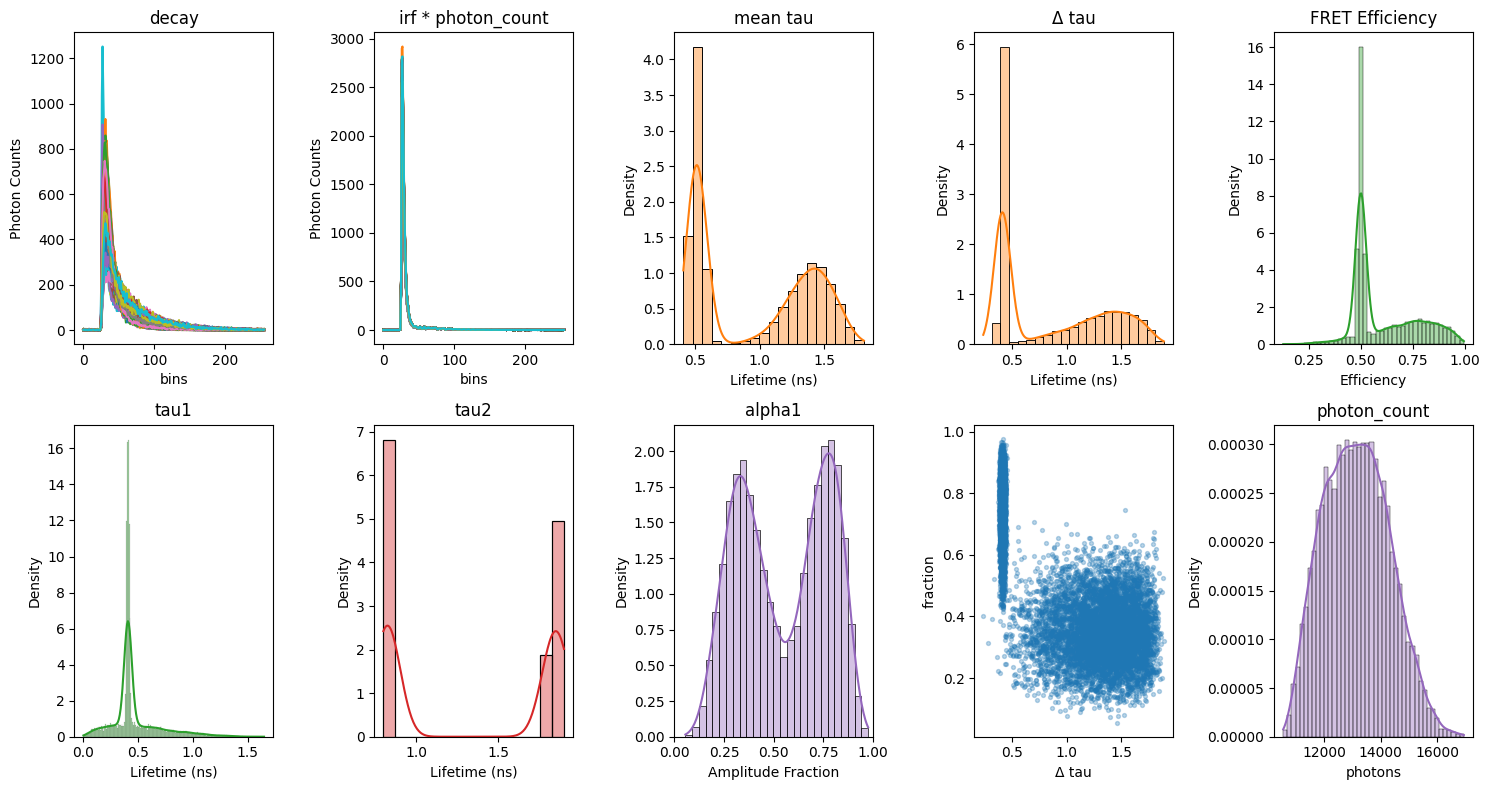

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

res_well = gt_data_well["results"]["maps"]

b_bool_mask_well_bool = b_bool_mask_well.astype(bool)
valid_px_well = np.argwhere(b_bool_mask_well)
rng_well = np.random.default_rng(0)
sample_idx_well = rng_well.choice(len(valid_px_well), size=min(300, len(valid_px_well)), replace=False)
sample_px_well = valid_px_well[sample_idx_well]
decay_sample_well = _decay_well[sample_px_well[:, 0], sample_px_well[:, 1], :]
irf_sample_well = _irf_well[sample_px_well[:, 0], sample_px_well[:, 1], :]
photon_count_sample_well = res_well["photon_count_map"][sample_px_well[:, 0], sample_px_well[:, 1]]

tau1_valid_well = res_well["tau1_map"][b_bool_mask_well_bool]
tau2_valid_well = res_well["tau2_map"][b_bool_mask_well_bool]
alpha1_valid_well = res_well["alpha1_map"][b_bool_mask_well_bool]
tau_mean_valid_well = res_well["tau_mean_map"][b_bool_mask_well_bool]
efficiency_valid_well = res_well["fret_efficiency_map"][b_bool_mask_well_bool]
photon_count_valid_well = res_well["photon_count_map"][b_bool_mask_well_bool]
tau_dif_well = tau2_valid_well - tau1_valid_well

fig, axes = plt.subplots(2, 5, figsize=(15, 8))

axes[0, 0].plot(decay_sample_well.T)
axes[0, 0].set_title("decay")
axes[0, 0].set_xlabel("bins")
axes[0, 0].set_ylabel("Photon Counts")

axes[0, 1].plot((irf_sample_well * photon_count_sample_well[:, None]).T)
axes[0, 1].set_title("irf * photon_count")
axes[0, 1].set_xlabel("bins")
axes[0, 1].set_ylabel("Photon Counts")

sns.histplot(data=tau_mean_valid_well, ax=axes[0, 2], kde=True, stat="density", color="tab:orange", alpha=0.4)
axes[0, 2].set_title("mean tau")
axes[0, 2].set_xlabel("Lifetime (ns)")

sns.histplot(data=tau_dif_well, ax=axes[0, 3], kde=True, stat="density", color="tab:orange", alpha=0.4)
axes[0, 3].set_title("Δ tau")
axes[0, 3].set_xlabel("Lifetime (ns)")

sns.histplot(data=efficiency_valid_well, ax=axes[0, 4], kde=True, stat="density", color="tab:green", alpha=0.4)
axes[0, 4].set_title("FRET Efficiency")
axes[0, 4].set_xlabel("Efficiency")

sns.histplot(data=tau1_valid_well, ax=axes[1, 0], kde=True, stat="density", color="tab:green", alpha=0.4)
axes[1, 0].set_title("tau1")
axes[1, 0].set_xlabel("Lifetime (ns)")

sns.histplot(data=tau2_valid_well, ax=axes[1, 1], kde=True, stat="density", color="tab:red", alpha=0.4)
axes[1, 1].set_title("tau2")
axes[1, 1].set_xlabel("Lifetime (ns)")

sns.histplot(data=alpha1_valid_well, ax=axes[1, 2], kde=True, stat="density", color="tab:purple", alpha=0.4)
axes[1, 2].set_title("alpha1")
axes[1, 2].set_xlabel("Amplitude Fraction")
axes[1, 2].set_xlim(0.0, 1.0)

axes[1, 3].scatter(tau_dif_well, alpha1_valid_well, s=8, alpha=0.3)
axes[1, 3].set_xlabel("Δ tau")
axes[1, 3].set_ylabel("fraction")

sns.histplot(data=photon_count_valid_well, ax=axes[1, 4], kde=True, stat="density", color="tab:purple", alpha=0.4)
axes[1, 4].set_title("photon_count")
axes[1, 4].set_xlabel("photons")

plt.tight_layout()
plt.show()

## Lifetime fitting: NLSF and MLE

For a bi-exponential model the fitted parameters are `[S, alpha1, tau1, tau2, v_shift, h_shift]`. Separating `alpha1`, `tau1` and `tau2` is harder than fitting a single lifetime, so the amplitude-weighted mean lifetime `tau_mean` is also compared below as the most robust summary of each pixel.

In [14]:
from pyfli.analysis.utils import plot_pixel_diagnostic
from pyfli.data_vnp import Plotter
from pyfli.solver import (
    BaseFLIFitter,
    BinnedFLIFitter,
    FittingComparator,
    FLICPUProcessor,
    MLEFLIFitter,
)

### Single-pixel fit: NLSF vs MLE

Before fitting the whole image, `FittingComparator` fits one randomly selected pixel with both estimators and plots the fits side by side:

- `"least_squares"` uses `BaseFLIFitter` (NLSF)
- `"poisson"` uses `MLEFLIFitter` (Poisson MLE)

`p0` (initial guess) and `bounds` are left as `None`, so the fitter derives its own initial guess from the data. Both can be passed in the parameter order given above.


┌──────────────────────────────────────────────────────────────┐
│  FLI Fitting Results  |  BI-EXPONENTIAL                      │
│  2 methods queued                                            │
└──────────────────────────────────────────────────────────────┘


┌────────────────┬──────┬─────────┬─────────┬──────────┬──────────┬─────────┬──────────┬──────────┬─────────┬──────────┐
│ Method         │ Type │       A │       α │       τ₁ │       τ₂ │      R² │   Red.χ² │   Raw.χ² │ v-shift │  h-shift │
├────────────────┼──────┼─────────┼─────────┼──────────┼──────────┼─────────┼──────────┼──────────┼─────────┼──────────┤
│ LEAST_SQUARES  │ NLSF │  581.21 │  0.3139 │    0.283 │    0.613 │  0.9968 │   0.9980 │   249.49 │    0.00 │   -0.001 │
│ POISSON        │ MLE  │  586.14 │  0.4410 │    0.320 │    0.684 │  0.9969 │   0.9191 │   229.78 │    0.12 │   -0.000 │
└────────────────┴──────┴─────────┴─────────┴──────────┴──────────┴─────────┴──────────┴──────────┴─────────┴──────────┘



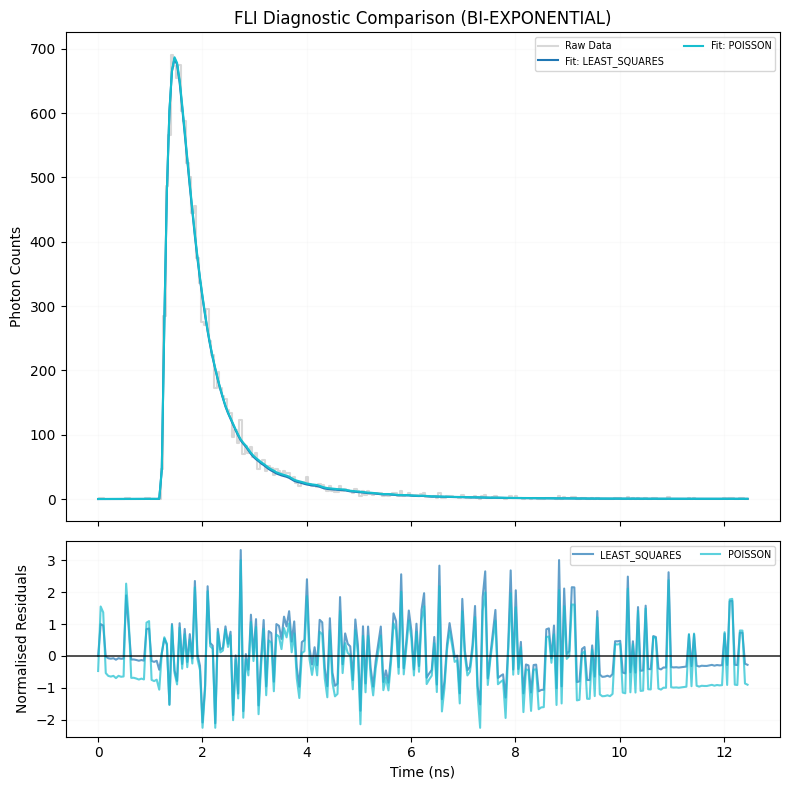

In [15]:
p0 = None
bounds = None

xd_well, yd_well = random_true_pixel(b_bool_mask_well)
pixel_decay_well = _decay_well[xd_well, yd_well, :]
pixel_irf_well = _irf_well[xd_well, yd_well, :]

comparator = FittingComparator(freq, BaseFLIFitter, MLEFLIFitter)
comp_results_table, comp_fig = comparator.compare_selected(
    ["least_squares", "poisson"],
    y_data=pixel_decay_well,
    irf_data=pixel_irf_well,
    model_type=MODEL_TYPE,
    p0=p0,
    bounds=bounds,
    yscale="linear",
    plot=True,
)

### Whole-image fitting

Each pixel is fitted independently and in parallel on the CPU:

- `FLICPUProcessor(freq, fitter_class)` spreads the per-pixel fits over `n_jobs` worker processes. The fitter class sets the estimator family.
- `BinnedFLIFitter(..., bin_radius=0)` is the image-level entry point. A `bin_radius` of 0 fits every pixel as-is, and a larger radius sums each pixel with its neighbours first to raise the photon count.
- `max_iter` caps the optimizer's function evaluations per pixel.

On a machine with a CUDA GPU, `FLIGPUProcessor` can be used in place of `FLICPUProcessor` to fit all pixels as one batch.

#### NLSF

In [16]:
MAX_ITER = 2000
N_JOBS = 7

nlsf_fitter = BinnedFLIFitter(FLICPUProcessor(freq, BaseFLIFitter), bin_radius=0)
results_nlsf = nlsf_fitter.fit(
    b_img=_decay_well,
    b_irf=_irf_well,
    estimator="least_squares",
    model_type=MODEL_TYPE,
    n_jobs=N_JOBS,
    data_name="simulated_wells_nlsf",
    max_iter=MAX_ITER,
)

INFO:pyfli:Engine: CPU Parallel Processor (via FLICPUProcessor)
Fitting Pixels (least_squares): 100%|██████████| 13226/13226 [00:54<00:00, 242.32px/s]


#### MLE

The same pipeline is run with `MLEFLIFitter` and the `"poisson"` estimator. MLE takes longer per pixel than NLSF.

In [17]:
MAX_ITER = 1500
mle_fitter = BinnedFLIFitter(FLICPUProcessor(freq, MLEFLIFitter), bin_radius=0)
results_mle = mle_fitter.fit(
    b_img=_decay_well,
    b_irf=_irf_well,
    estimator="poisson",
    model_type=MODEL_TYPE,
    n_jobs=N_JOBS,
    data_name="simulated_wells_mle",
    max_iter=MAX_ITER,
)

INFO:pyfli:Engine: CPU Parallel Processor (via FLICPUProcessor)
Fitting Pixels (poisson): 100%|██████████| 13226/13226 [05:17<00:00, 41.70px/s]


## Comparing the results

Every fit result has the same layout: `results["results"]["maps"]` holds the parameter maps (`alpha1_map`, `tau1_map`, `tau2_map`, `tau_mean_map`, `R2_map`, `reduced_chi2_map`, ...), and `results["results"]["TR_maps"]` holds the per-pixel fitted curves (`fit_map`) and residuals (`residual_map`).

### Parameter maps

Rows: ground truth, NLSF, MLE. The lifetime color range is shared across rows and set from the ground truth.

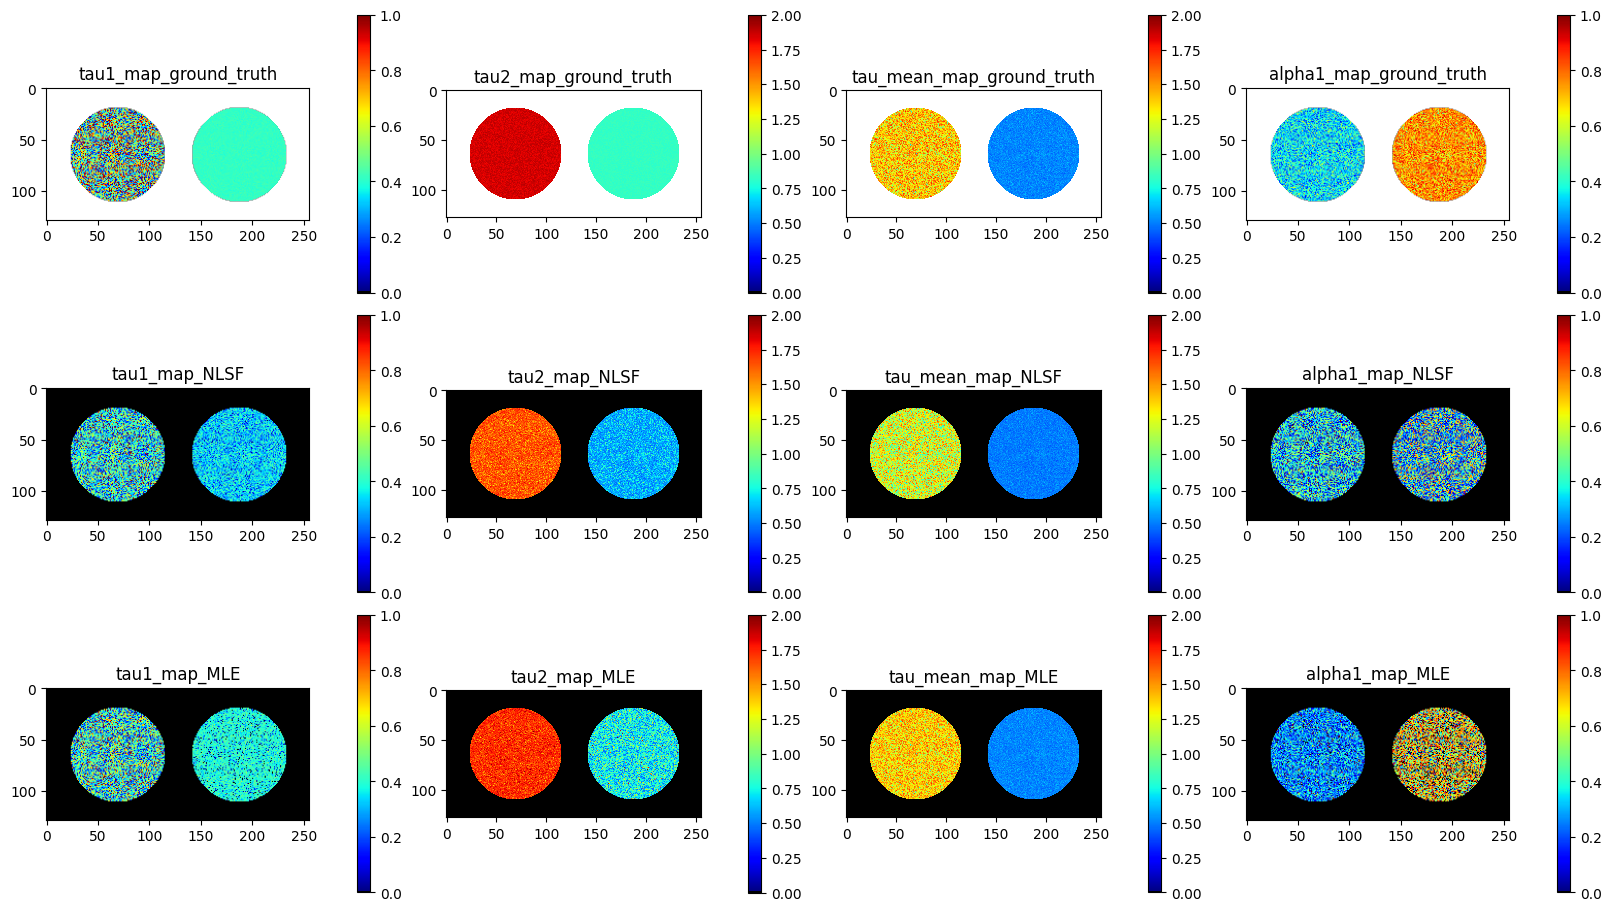

In [18]:
experiments = {"NLSF": results_nlsf, "MLE": results_mle}
all_datasets = [res["results"]["maps"] for res in experiments.values()]
all_fitset = [res["results"]["TR_maps"] for res in experiments.values()]

keys_to_plot = ["tau1_map", "tau2_map", "tau_mean_map", "alpha1_map",]
sources = {"ground_truth": res_well, **dict(zip(experiments, all_datasets))}
tau_max = float(max(res_well["tau1_map"].max(), res_well["tau2_map"].max()))

_ = DataViewer().display_data(
    [maps[key] for maps in sources.values() for key in keys_to_plot],
    structure=(len(sources), len(keys_to_plot)),
    coord=None,
    data_names=[f"{key}_{name}" for name in sources for key in keys_to_plot],
    cmaps=[jet_m_well] * len(sources) * len(keys_to_plot),
    v_ranges=[(0, 1), (0, 2), (0, 2), (0, 1)] * len(sources),
    figsize=(16, 9),
    normalize=False,
    yscale="linear",
)

### Parameter distributions

`Plotter` compares the parameter values of the well pixels across the sources. The `operations` dict is applied to every source: it keeps only pixels inside the mask, drops failed fits (NaN or zero) and discards values outside the threshold range. A list of dicts, one per source, can be passed instead to filter each source differently.

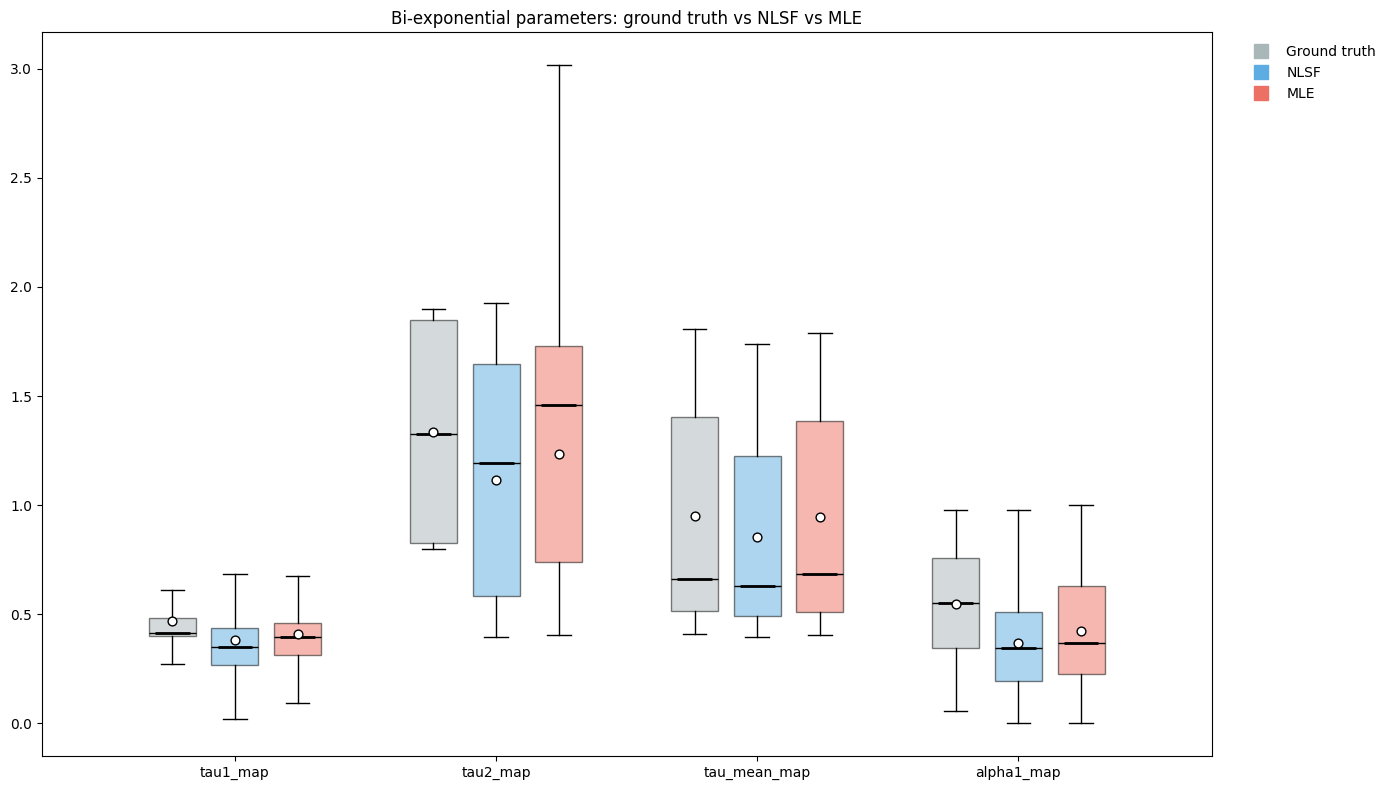

In [19]:
names = ["Ground truth"] + list(experiments)
plotter_ops = {
    "mask": b_bool_mask_well.ravel(),
    "remove_nan": True,
    "remove_zero": True,
    "threshold": (0, 7),
}

painter = Plotter(
    res_well,
    *all_datasets,
    values=keys_to_plot,
    style_config=["#AAB7B8", "#5DADE2", "#EC7063"],
    source_names=names,
    operations=plotter_ops,
)

fig = painter.make_plot(
    title="Bi-exponential parameters: ground truth vs NLSF vs MLE",
    graph_type="box",
    point_type="strip",
    show_mean=True,
    show_median=True,
    show_significance=True,
    test_type="none",
    correction=False,
)

`graph_type` can also be `"box"`, `"swarm"`, `"overlay"`, `"raincloud"` or `"kde"`. Setting `test_type` to `"paired"` or `"welch"` adds significance tests between the sources.

### Fits at a single pixel

`plot_pixel_diagnostic` overlays the NLSF and MLE fitted curves on the measured decay at one pixel, with the residuals below.

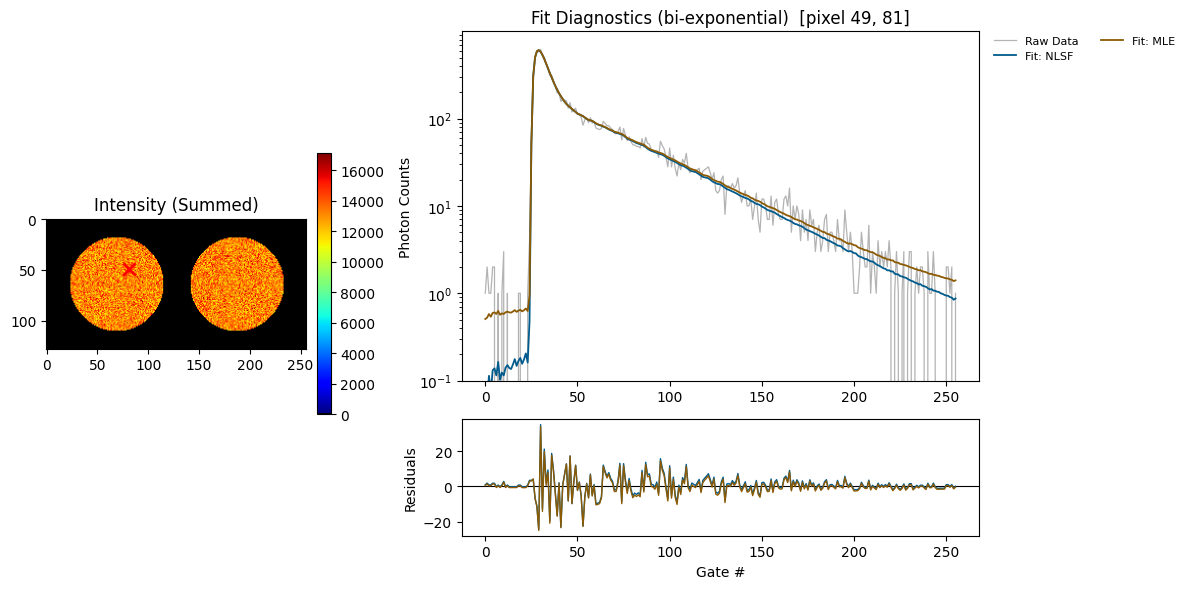

In [20]:
x_well, y_well = random_true_pixel(b_bool_mask_well)
_ = plot_pixel_diagnostic(
    _decay_well,
    all_fitset,
    list(experiments),
    mask=b_bool_mask_well,
    pixel=(x_well, y_well),
    t=None,
    yscale="log",
    raw_style="line",
    model_type=MODEL_TYPE,
)

The same pixel is shown for each estimator, along with the fitted parameters and goodness-of-fit metrics (R², reduced χ²). The ground-truth values at this pixel are printed first for reference.

INFO:pyfli:
  Pixel (49, 81)
  ─────────────────────
  A         12239.4473
  α         0.3822
  τ₁        0.1586
  τ₂        1.8334
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   0.0000
  h-shift   —
  ─────────────────────



the non-zero pixel selected for probing is (49, 81)
--- Ground truth ---
--- NLSF ---


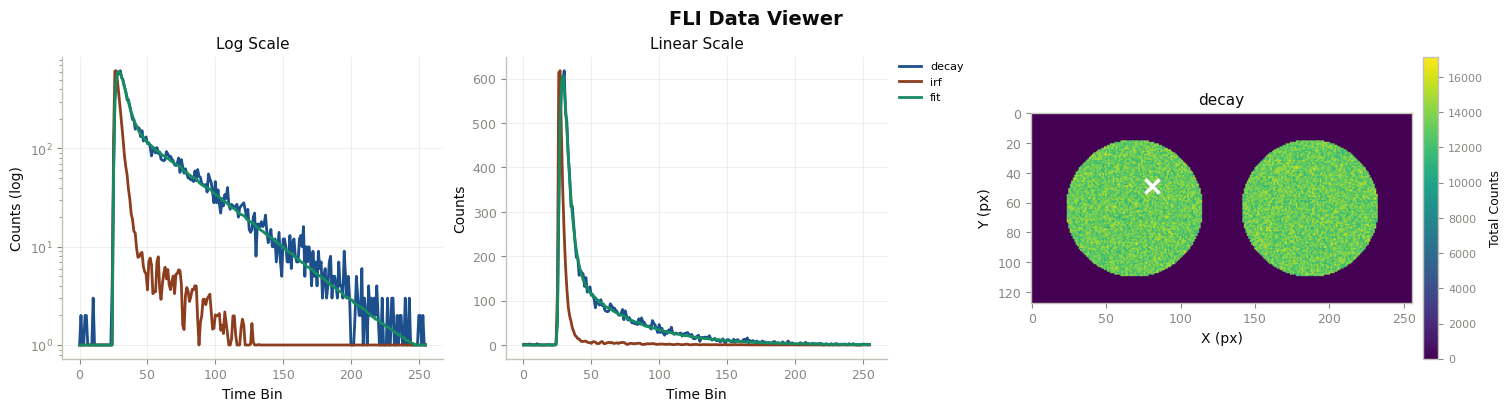

INFO:pyfli:
  Pixel (49, 81)
  ─────────────────────
  A         725.8046
  α         0.4923
  τ₁        0.1573
  τ₂        1.7656
  R²        0.9962
  Red.χ²    1.0715
  Raw.χ²    267.8745
  v-shift   0.0563
  h-shift   -0.0919
  ─────────────────────



--- MLE ---


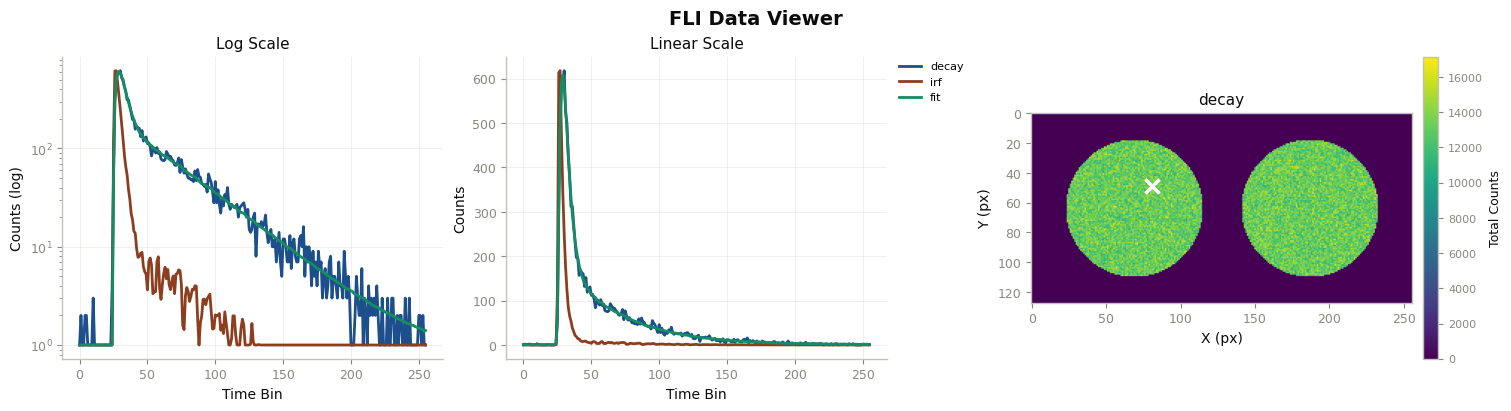

INFO:pyfli:
  Pixel (49, 81)
  ─────────────────────
  A         553.5249
  α         0.3642
  τ₁        0.1590
  τ₂        1.8112
  R²        0.9964
  Red.χ²    0.8832
  Raw.χ²    220.8033
  v-shift   0.5209
  h-shift   -0.0001
  ─────────────────────



In [21]:
print(f"the non-zero pixel selected for probing is ({x_well}, {y_well})")
print("--- Ground truth ---")
_ = MessageDisplay().get_pixel_summary(data_maps=res_well, px=(x_well, y_well))
for name, maps, TRs in zip(experiments, all_datasets, all_fitset):
    print(f"--- {name} ---")
    DataViewer().plot_fli_px(
        data_list=[_decay_well, irf_norm_well, TRs["fit_map"], TRs["residual_map"]],
        pixel=(x_well, y_well),
        mode=[0, 1, 2],
        mode2=[0],
        names=["decay", "irf", "fit"],
    )
    _ = MessageDisplay().get_pixel_summary(data_maps=maps, px=(x_well, y_well))

## Phasor computation and visualization

In [12]:
time_axis_ns_well = np.linspace(0, gate_delay * num_gates, _irf_well.shape[2])
phasor_well = PhasorAnalyzer(
    frequency_hz=freq_hz, time_axis_ns=time_axis_ns_well, n_harmonics=3
)
G_well, S_well = phasor_well.create_phasor_gpu(_decay_well)
Gc_well, Sc_well = phasor_well.calibrate_pixelwise(G_well, S_well, _irf_well)
tau_map_ns_well = phasor_well.compute_lifetime(Gc_well[0], Sc_well[0])

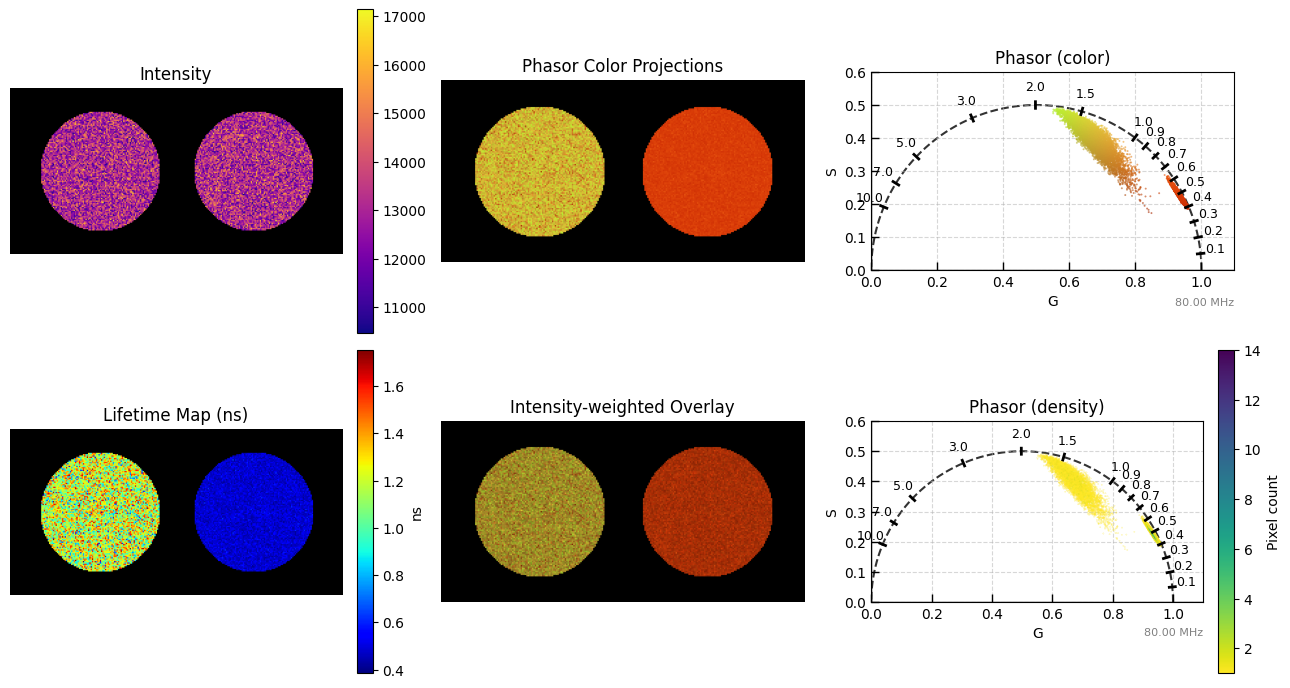

In [13]:
im2_well = phasor_well.plot_overlay_subplots(
    _decay_well,
    Gc_well[0],
    Sc_well[0],
    mask=b_bool_mask_well,
    colormaps=["plasma", "jet", "turbo_r", ph_cols_],
    figsize=(13, 7),
    xlim=(0, 1.1),
    bg_color=bg_color,
    transpose=False,
    kdeplot=False,
)

## Summary

- **NLSF** (`BaseFLIFitter`, `"least_squares"`) is the faster option and a good default for pixels with high photon counts.
- **MLE** (`MLEFLIFitter`, `"poisson"`) models photon-counting noise directly and is preferred at low photon counts, at the cost of longer fitting time.
- For bi-exponential data, `tau_mean` is generally recovered more reliably.
- Both estimators return results with the same structure, so the maps, distributions and pixel diagnostics above can be produced for either one, or for any other fitter in `pyfli.solver`.